In [75]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
from matplotlib import rcParams
import matplotlib.font_manager as fm
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5

In [77]:
import sys
import os
import pandas as pd
import numpy as np
from os.path import join as pjoin

from catrace.stats import sort_conditions, pool_training_conditions
from catrace.visualize import plot_measure, plot_all_measures

paper_fig_dir = '../../figures_for_paper/juvenile/capacity'
os.makedirs(paper_fig_dir, exist_ok=True)
dataset_name = 'juvenile'

In [78]:
measure_names = ['capacity', 'radius', 'dimension', 'axes_alignment', 'center_alignment', 'center_axes_alignment']
align_measure_names = ['axes_alignment', 'center_alignment', 'center_axes_alignment']


In [79]:
def load_juvenile_capacities(jobname, analysis_dir):
    jobfile = pjoin(analysis_dir, f'df_result.pkl')
    df_result = pd.read_pickle(jobfile)
    df_per_fish_juv = df_result.xs(False, level='shuffle').groupby(['fish_id', 'condition', 'odor1', 'odor2'], sort=False).mean()
    df_per_fish_juv_shuffled = df_result.xs(True, level='shuffle').groupby(['fish_id', 'condition', 'odor1', 'odor2'], sort=False).mean()

    juv_conditions =  ['naive', 'arg-phe', 'phe-arg', 'phe-trp']
    cond_mapping = {'naive': 'naive', 'phe-arg': 'trained', 'arg-phe': 'trained', 'phe-trp': 'trained'}
    conditions_pooled = ['naive', 'trained']

    df_pooled = pool_training_conditions(df_per_fish_juv, cond_mapping, keep_subconditions=True)

    df_pooled_shuffled = pool_training_conditions(df_per_fish_juv_shuffled, cond_mapping, keep_subconditions=True)
    return df_per_fish_juv, df_per_fish_juv_shuffled,df_pooled, df_pooled_shuffled, juv_conditions, cond_mapping, conditions_pooled


## Juvenile

In [80]:
import sys
import os
import pandas as pd
from os.path import join as pjoin


dataset_name = 'juvenile'
config_file = '../dataset_configs/juvenile_dataset_t7.json'


from analysis_config import juvenile_window_name_to_frames, juvenile_capacity_window_name_to_M, juvenile_capacity_window_name_to_seed
window_name = 'time_window_7s'
window = juvenile_window_name_to_frames[window_name]
print(window_name, window)
window_tag = f'window_{window[0]}to{window[1]}'

import sys
import os
import pandas as pd
from os.path import join as pjoin

from catrace.dataset import load_dataset_config
window_key = f'window_{window[0]}_{window[1]}'

M = juvenile_capacity_window_name_to_M[window_name]
seed = juvenile_capacity_window_name_to_seed[window_name]
N=700 # number of neurons

dsconfig= load_dataset_config(config_file)
capacity_dir = os.path.join(dsconfig.results_dir, 'capacity')

jobname = f'capacity_sweep_{window_key}_N{N}_M{M}_master_seed{seed}'
# Load the capacity dataframe
import pandas as pd

input_dir = pjoin(capacity_dir, jobname)
exp_list = dsconfig.exp_list
conditions = dsconfig.conditions


df_per_fish_juv, df_per_fish_juv_shuffled,df_pooled, df_pooled_shuffled, juv_conditions, cond_mapping, conditions_pooled = load_juvenile_capacities('', input_dir)

time_window_7s [32, 85]


### Each AA vs all BA


naivearg-phe
[('Phe', 'TCA'), ('GCA', 'Phe'), ('Phe', 'TDCA')]
[('Arg', 'TCA'), ('Arg', 'TDCA'), ('Arg', 'GCA')]
[('TDCA', 'Trp'), ('TCA', 'Trp'), ('GCA', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


naivephe-arg
[('Phe', 'TCA'), ('GCA', 'Phe'), ('Phe', 'TDCA')]
[('Arg', 'TCA'), ('Arg', 'TDCA'), ('Arg', 'GCA')]
[('TDCA', 'Trp'), ('TCA', 'Trp'), ('GCA', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


naivephe-trp
[('Phe', 'TCA'), ('GCA', 'Phe'), ('Phe', 'TDCA')]
[('Arg', 'TCA'), ('Arg', 'TDCA'), ('Arg', 'GCA')]
[('TDCA', 'Trp'), ('TCA', 'Trp'), ('GCA', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


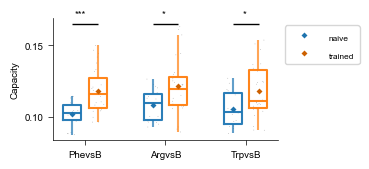

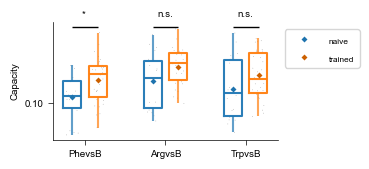

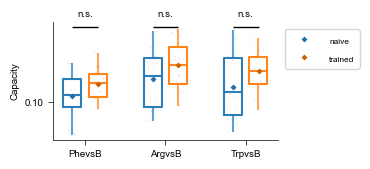

In [81]:
from catrace.for_paper import save_figure_for_paper, save_stats_json
def select_condition_multi_vs(selected_conditions):
    df_pooled_sel = df_pooled[df_pooled.index.get_level_values('subcondition').isin(selected_conditions)]
    df_pooled_sel_shuffled = df_pooled_shuffled[df_pooled_shuffled.index.get_level_values('subcondition').isin(selected_conditions)]
    selected_conditions_tag = ''.join(selected_conditions)
    print(selected_conditions_tag)
    dataset_name = 'juvenile'


    vsdict = {
        'PhevsB': (['Phe'], ['TDCA', 'TCA', 'GCA']),
        'ArgvsB': (['Arg'], ['TDCA', 'TCA', 'GCA']),
        'TrpvsB': (['Trp'], ['TDCA', 'TCA', 'GCA']),
    }

    from catrace.capacity_utils import get_per_vs
    vsdff = get_per_vs(vsdict, df_pooled_sel)

    from catrace.visualize import (plot_measure_multi_odor_cond,
                                PlotBoxplotMultiOdorCondParams,
                                set_yticks_interval)
    plot_box_multi_params = PlotBoxplotMultiOdorCondParams(
            figsize=(3.8, 1.8),
            label_fontsize=7,
            show_ns=True,
            strip_size=0.5,
            mean_marker_size=1,
            pvalue_marker_xoffset=0.05,
            do_capitalize_labels=True,
        )
    fig, ax, test_results = plot_measure_multi_odor_cond(vsdff, 'capacity', odor_name='vsname', condition_name='condition', params=plot_box_multi_params)

    set_yticks_interval(ax, 0.05)

    figname = f'{dataset_name}_{selected_conditions_tag}_capacity_vsname'
    save_figure_for_paper(fig, figname, paper_fig_dir)
    # save_stats_json(test_results, figname, paper_fig_dir, tuple_key_to_str=True)

select_condition_multi_vs(['naive', 'arg-phe'])
select_condition_multi_vs(['naive', 'phe-arg'])
select_condition_multi_vs(['naive', 'phe-trp'])

arg-phe
[('Phe', 'TCA'), ('GCA', 'Phe'), ('Phe', 'TDCA')]
[('Arg', 'TCA'), ('Arg', 'TDCA'), ('Arg', 'GCA')]
[('TDCA', 'Trp'), ('TCA', 'Trp'), ('GCA', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


phe-arg
[('Phe', 'TCA'), ('GCA', 'Phe'), ('Phe', 'TDCA')]
[('Arg', 'TCA'), ('Arg', 'TDCA'), ('Arg', 'GCA')]
[('TDCA', 'Trp'), ('TCA', 'Trp'), ('GCA', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


phe-trp
[('Phe', 'TCA'), ('GCA', 'Phe'), ('Phe', 'TDCA')]
[('Arg', 'TCA'), ('Arg', 'TDCA'), ('Arg', 'GCA')]
[('TDCA', 'Trp'), ('TCA', 'Trp'), ('GCA', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


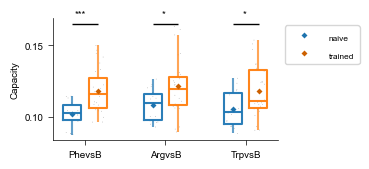

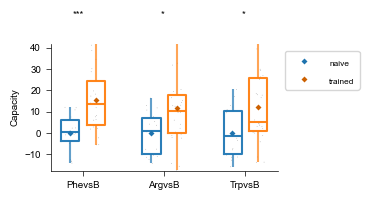

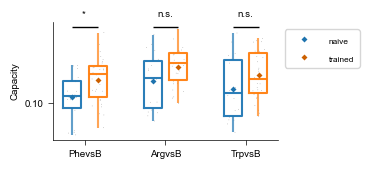

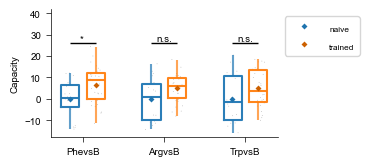

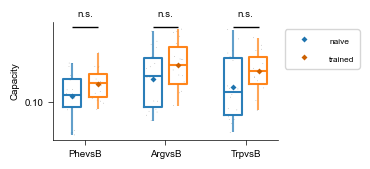

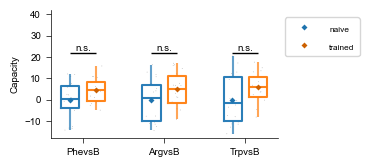

In [82]:
from catrace.capacity_utils import compute_vsdff_percent

def select_condition_multi_vs(selected_conditions, perc_ylim=None):
    # selected_conditions should be of length 2 and the fist element should be 'naive'
    assert len(selected_conditions) == 2
    assert selected_conditions[0] == 'naive'

    df_pooled_sel = df_pooled[df_pooled.index.get_level_values('subcondition').isin(selected_conditions)]
    df_pooled_sel_shuffled = df_pooled_shuffled[df_pooled_shuffled.index.get_level_values('subcondition').isin(selected_conditions)]
    selected_conditions_tag = selected_conditions[1]
    print(selected_conditions_tag)
    dataset_name = 'juvenile'

    vsdict = {
        'PhevsB': (['Phe'], ['TDCA', 'TCA', 'GCA']),
        'ArgvsB': (['Arg'], ['TDCA', 'TCA', 'GCA']),
        'TrpvsB': (['Trp'], ['TDCA', 'TCA', 'GCA']),
    }

    from catrace.capacity_utils import get_per_vs
    vsdff = get_per_vs(vsdict, df_pooled_sel)

    from catrace.visualize import (plot_measure_multi_odor_cond,
                                PlotBoxplotMultiOdorCondParams,
                                set_yticks_interval)
    plot_box_multi_params = PlotBoxplotMultiOdorCondParams(
            figsize=(3.8, 1.8),
            label_fontsize=7,
            show_ns=True,
            strip_size=0.5,
            mean_marker_size=1,
            pvalue_marker_xoffset=0.05,
            do_capitalize_labels=True,
        )
    fig, ax, test_results = plot_measure_multi_odor_cond(vsdff, 'capacity', odor_name='vsname', condition_name='condition', params=plot_box_multi_params)

    set_yticks_interval(ax, 0.05)

    vsdff_percent = compute_vsdff_percent(vsdff)
    fig_percent, ax, test_results = plot_measure_multi_odor_cond(vsdff_percent, 'capacity', odor_name='vsname', condition_name='condition', params=plot_box_multi_params)
    if perc_ylim is not None:
        ax.set_ylim(perc_ylim)

    figname = f'{dataset_name}_AA_{selected_conditions_tag}_capacity_vsname_AAvsB'
    save_figure_for_paper(fig, figname, paper_fig_dir)
    figname_percent = f'{dataset_name}_AA_{selected_conditions_tag}_capacity_vsname_percent_AAvsB'
    save_figure_for_paper(fig_percent, figname_percent, paper_fig_dir)
    # save_stats_json(test_results, figname, paper_fig_dir, tuple_key_to_str=True)

    return vsdff, vsdff_percent


trained_conditions = ['arg-phe', 'phe-arg', 'phe-trp']

vsdffs = {}
vsdff_percents = {}
perc_ylim = (-18, 42)
for trained_condition in trained_conditions:
    vsdff, vsdff_percent = select_condition_multi_vs(['naive', trained_condition], perc_ylim=perc_ylim)
    vsdffs[trained_condition] = vsdff
    vsdff_percents[trained_condition] = vsdff_percent

### Learned AA vs novel AA

arg-phe
[('Arg', 'Phe')]
[('Phe', 'Trp')]
[('Arg', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\AppData\Local\Temp\ipykernel_19812\2568793058.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


phe-arg
[('Arg', 'Phe')]
[('Phe', 'Trp')]
[('Arg', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\AppData\Local\Temp\ipykernel_19812\2568793058.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


phe-trp
[('Arg', 'Phe')]
[('Phe', 'Trp')]
[('Arg', 'Trp')]


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(
C:\Users\hubob\AppData\Local\Temp\ipykernel_19812\2568793058.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


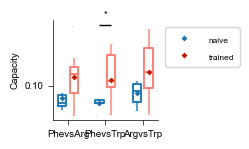

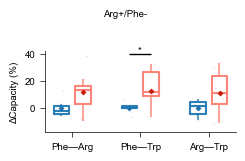

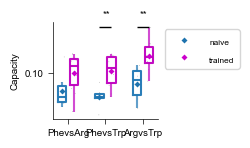

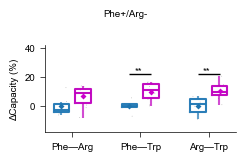

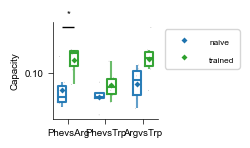

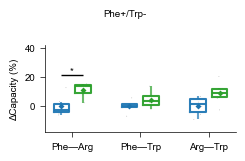

In [83]:
from catrace.capacity_utils import compute_vsdff_percent

def select_condition_multi_vs(selected_conditions, perc_ylim=None, second_box_color='tab:orange'):
    # selected_conditions should be of length 2 and the fist element should be 'naive'
    assert len(selected_conditions) == 2
    assert selected_conditions[0] == 'naive'

    df_pooled_sel = df_pooled[df_pooled.index.get_level_values('subcondition').isin(selected_conditions)]
    df_pooled_sel_shuffled = df_pooled_shuffled[df_pooled_shuffled.index.get_level_values('subcondition').isin(selected_conditions)]
    selected_conditions_tag = selected_conditions[1]
    print(selected_conditions_tag)
    dataset_name = 'juvenile'


    vsdict = {
        'PhevsArg': (['Phe'], ['Arg']),
        'PhevsTrp': (['Phe'], ['Trp']),
        'ArgvsTrp': (['Arg'], ['Trp']),
    }

    from catrace.capacity_utils import get_per_vs
    vsdff = get_per_vs(vsdict, df_pooled_sel)

    from catrace.visualize import (plot_measure_multi_odor_cond,
                                PlotBoxplotMultiOdorCondParams,
                                set_yticks_interval)
    plot_box_multi_params = PlotBoxplotMultiOdorCondParams(
            figsize=(2.6, 1.6),
            label_fontsize=7,
            strip_size=0.5,
            mean_marker_size=1,
            pvalue_marker_xoffset=0.05,
            do_capitalize_labels=True,
            show_ns=False,
            hue_colors=['tab:blue', second_box_color]
        )
    fig, ax, test_results = plot_measure_multi_odor_cond(vsdff, 'capacity', odor_name='vsname', condition_name='condition', params=plot_box_multi_params)

    set_yticks_interval(ax, 0.05)

    vsdff_percent = compute_vsdff_percent(vsdff)
    fig_percent, ax, test_results_percent = plot_measure_multi_odor_cond(vsdff_percent, 'capacity', odor_name='vsname', condition_name='condition', params=plot_box_multi_params)

    figname = f'{dataset_name}_AA_{selected_conditions_tag}_capacity_vsname'
    save_figure_for_paper(fig, figname, paper_fig_dir)
    figname_percent = f'{dataset_name}_AA_{selected_conditions_tag}_capacity_vsname_percent'

    ax = fig_percent.get_axes()[0]
    ax.set_ylabel('ΔCapacity (%)')

    if perc_ylim is not None:
        ax.set_ylim(perc_ylim)

    xtick_labels = ax.get_xticklabels()
    mapping = {'PhevsArg': 'Phe—Arg', 'PhevsTrp': 'Phe—Trp', 'ArgvsTrp': 'Arg—Trp'}
    xtick_labels = [mapping[label.get_text()] for label in xtick_labels]
    ax.set_xticklabels(xtick_labels)

    if ax.get_legend():
        ax.get_legend().remove()

    plus_minus = selected_conditions_tag.split('-')
    # Capitalize plus_minus
    plus_minus = [pm.capitalize() for pm in plus_minus]
    condition_text = f'{plus_minus[0]}+/{plus_minus[1]}-'
    fig_percent.suptitle(condition_text, fontsize=7)
    fig_percent.tight_layout()

    save_figure_for_paper(fig_percent, figname_percent, paper_fig_dir)
    # save_stats_json(test_results, figname, paper_fig_dir, tuple_key_to_str=True)

    return vsdff, vsdff_percent, test_results_percent


trained_conditions = ['arg-phe', 'phe-arg', 'phe-trp']

vsdffs = {}
vsdff_percents = {}
test_results_percents = {}

perc_ylim = (-18, 42)
condition_color_mapping = {'naive': 'tab:blue', 
              'arg-phe': 'salmon',
              'phe-arg': 'm',
              'phe-trp': 'tab:green',
}
for trained_condition in trained_conditions:
    vsdff, vsdff_percent,test_results_percent = select_condition_multi_vs(['naive', trained_condition], perc_ylim=perc_ylim, second_box_color=condition_color_mapping[trained_condition])
    vsdffs[trained_condition] = vsdff
    vsdff_percents[trained_condition] = vsdff_percent
    test_results_percents[trained_condition] = test_results_percent


In [84]:
vsdff_percents['arg-phe']['capacity']

# concatenate vsdff_percent['capacity'] for all trained conditions
vsdff_percent_all_trained = pd.concat([vsdff_percents[cond]['capacity'] for cond in trained_conditions], axis=0)

vsdff_percent_all_trained

# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure07')
os.makedirs(save_dir, exist_ok=True)
vsdff_percent_all_trained.to_csv(os.path.join(save_dir, f'extended_figure07b_juvenile_capacity_and_geometric_measures_learned_novel.csv'))

In [85]:
from catrace.stats import format_test_results_multi_odor_two_cond
sentence = format_test_results_multi_odor_two_cond(test_results_percents['phe-arg'])
print(sentence)

For ArgvsTrp, Comparing naive (mean = 1.48e-16 ± 6.27, n = 6) vs trained (mean = 10.19 ± 5.49, n = 10): Mann–Whitney U test, U = 5.00, P = 0.005. For PhevsArg, Comparing naive (mean = 1.98e-14 ± 6.94, n = 6) vs trained (mean = 6.66 ± 7.32, n = 10): Mann–Whitney U test, U = 15.00, P = 0.118. For PhevsTrp, Comparing naive (mean = -1.11e-16 ± 4.07, n = 6) vs trained (mean = 9.87 ± 6.13, n = 10): Mann–Whitney U test, U = 6.00, P = 0.007.


In [86]:
trained_condition = 'phe-trp'
sub_percent_trained = vsdff_percents[trained_condition].xs('trained', level='condition')
measure_name = 'capacity'
from catrace.stats import apply_test_by_cond
vs_test_trained = apply_test_by_cond(sub_percent_trained, measure_name, cond_name='vsname', return_all_pairs=True)
from catrace.stats import format_test_results_by_cond
sentence = format_test_results_by_cond(vs_test_trained)
print('trained')
print(sentence)
print(vs_test_trained['Dunn_all_pairs']['p_values'])

  Contrast         A         B  Paired  Parametric         T   dof  \
0   vsname  ArgvsTrp  PhevsArg   False        True -0.613631  10.0   
1   vsname  ArgvsTrp  PhevsTrp   False        True  1.178780  10.0   
2   vsname  PhevsArg  PhevsTrp   False        True  2.194465  10.0   

  alternative     p_unc   BF10    hedges  
0   two-sided  0.553161  0.527 -0.327028  
1   two-sided  0.265773  0.717  0.628218  
2   two-sided  0.052935  1.757  1.169515  
trained
(Kruskal–Wallis test, n = 18, d.f. = 2, H = 3.82, P = 0.148). Group statistics: ArgvsTrp: mean = 8.99 ± 7.61 (n = 6); PhevsArg: mean = 11.30 ± 5.23 (n = 6); and PhevsTrp: mean = 4.44 ± 5.59 (n = 6). Nonparametric multiple comparisons between all groups: ArgvsTrp (n = 6) vs PhevsArg (n = 6), Q = -0.61, P = 1.000; ArgvsTrp (n = 6) vs PhevsTrp (n = 6), Q = 1.18, P = 0.797; and PhevsArg (n = 6) vs PhevsTrp (n = 6), Q = 2.19, P = 0.159.
{('ArgvsTrp', 'PhevsArg'): 1.0, ('ArgvsTrp', 'PhevsTrp'): 0.7973179129091048, ('PhevsArg', 'PhevsTrp'):

In [87]:
# Pool vsdff_percents

aa_odors = ['Phe', 'Arg', 'Trp']
vsdff_percent_with_csvsnames = {}
for trained_condition in trained_conditions:
    learned_odors = trained_condition.split('-')
    # capitalize odors
    learned_odors = [odor.capitalize() for odor in learned_odors]
    novel_odor = [odor for odor in aa_odors if odor not in learned_odors][0]

    plus_novel_odors = sorted([learned_odors[0], novel_odor])
    plus_vs_novel1 = f'{plus_novel_odors[0]}vs{plus_novel_odors[1]}'
    plus_vs_novel2 = f'{plus_novel_odors[1]}vs{plus_novel_odors[0]}'
    minus_novle_odors = sorted([learned_odors[1], novel_odor])
    minus_vs_novel1 = f'{minus_novle_odors[0]}vs{minus_novle_odors[1]}'
    minus_vs_novel2 = f'{minus_novle_odors[1]}vs{minus_novle_odors[0]}'
    plus_minus_odors = sorted(learned_odors)
    plus_vs_minus1 = f'{plus_minus_odors[0]}vs{plus_minus_odors[1]}'
    plus_vs_minus2 = f'{plus_minus_odors[1]}vs{plus_minus_odors[0]}'

    vsname_mapping = {plus_vs_novel1: 'plus_vs_novel',
                        plus_vs_novel2: 'plus_vs_novel',
                        minus_vs_novel1: 'minus_vs_novel',
                        minus_vs_novel2: 'minus_vs_novel',
                        plus_vs_minus1: 'plus_vs_minus',
                        plus_vs_minus2: 'plus_vs_minus'}
    
    vsdff_percent = vsdff_percents[trained_condition]
    # Remove the naive condition and create a copy
    vsdff_percent = vsdff_percent.loc[vsdff_percent.index.get_level_values('condition') != 'naive'].copy()
    vsdff_percent['csvsname'] = vsdff_percent.index.get_level_values('vsname').map(vsname_mapping)
    vsdff_percent_with_csvsnames[trained_condition] = vsdff_percent


# concatenate vsdff_percent_with_csvsname
vsdff_csvs = pd.concat(vsdff_percent_with_csvsnames.values(), keys=vsdff_percent_with_csvsnames.keys(), names=['trained_condition'])
vsdff_csvs.set_index('csvsname', append=True, inplace=True)

In [88]:
measure_name = 'capacity'
from catrace.stats import apply_test_by_cond
vs_test_trained = apply_test_by_cond(vsdff_csvs, measure_name, cond_name='csvsname', return_all_pairs=True)
from catrace.stats import format_test_results_by_cond
sentence = format_test_results_by_cond(vs_test_trained)
print(sentence)

   Contrast               A              B  Paired  Parametric         T  \
0  csvsname  minus_vs_novel  plus_vs_minus   False        True  1.033557   
1  csvsname  minus_vs_novel  plus_vs_novel   False        True  0.016130   
2  csvsname   plus_vs_minus  plus_vs_novel   False        True -0.986160   

    dof alternative     p_unc   BF10    hedges  
0  48.0   two-sided  0.306523  0.438  0.287742  
1  48.0   two-sided  0.987198  0.283  0.004491  
2  48.0   two-sided  0.329000  0.421 -0.274547  
(Kruskal–Wallis test, n = 75, d.f. = 2, H = 1.59, P = 0.451). Group statistics: minus_vs_novel: mean = 10.81 ± 9.52 (n = 25); plus_vs_minus: mean = 7.89 ± 10.46 (n = 25); and plus_vs_novel: mean = 10.77 ± 10.18 (n = 25). Nonparametric multiple comparisons between all groups: minus_vs_novel (n = 25) vs plus_vs_minus (n = 25), Q = 1.03, P = 0.920; minus_vs_novel (n = 25) vs plus_vs_novel (n = 25), Q = 0.02, P = 1.000; and plus_vs_minus (n = 25) vs plus_vs_novel (n = 25), Q = -0.99, P = 0.987.


In [89]:
# if 'xcsvsname' is not in vsdff_csvs.columns:
if 'xcsvsname' not in vsdff_csvs.index.names:
    vsdff_csvs['xcsvsname'] = vsdff_csvs.index.get_level_values('csvsname').map({'plus_vs_minus': 'learned_vs_learned', 'plus_vs_novel': 'learned_vs_novel', 'minus_vs_novel': 'learned_vs_novel'})
    vsdff_csvs.set_index('xcsvsname', append=True, inplace=True)

from catrace.stats import apply_test_pair, format_test_results_pair
vs_test_trained = apply_test_pair(vsdff_csvs, yname=measure_name, condition_name='xcsvsname', group_name1='learned_vs_learned', group_name2='learned_vs_novel')
format_test_results_pair(vs_test_trained)

'Comparing learned_vs_learned (mean = 7.89 ± 10.46, n = 25) vs learned_vs_novel (mean = 10.79 ± 9.76, n = 50): Mann–Whitney U test, U = 516.00, P = 0.223.'

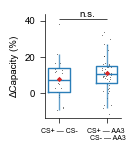

In [90]:
from catrace.visualize import plot_measure
from catrace.visualize import PlotBoxplotParams

plot_measure_params = PlotBoxplotParams(
    figsize=(1.6, 1.55),
    y_tick_label_fontsize=7,
    x_tick_label_fontsize=6,
    box_linewidth=1,
    mean_marker_size=0.7,
    strip_size=0.7,
    pvalue_bar_linewidth=0.5,
    box_colors=['tab:blue', 'tab:blue'],
    do_capitalize_labels=True,
)

measure_name = 'capacity'
fig, test_results_raw = plot_measure(vsdff_csvs, measure_name=measure_name,
                                     condition_name='xcsvsname', 
                                     group_name1='learned_vs_learned', 
                                     group_name2='learned_vs_novel', 
                                     params=plot_measure_params)
ax = fig.get_axes()[0]
ax.set_ylabel(f'ΔCapacity (%)', fontsize=7)

xtick_labels = ax.get_xticklabels()
mapping = {'Learned_vs_learned': 'CS+ — CS-', 'Learned_vs_novel': 'CS+ — AA3 \n CS- — AA3'}
xtick_labels = [mapping[label.get_text()] for label in xtick_labels]
ax.set_xticklabels(xtick_labels, fontsize=5)

# Rotate xticklabels 45 degrees
#for tick in ax.get_xticklabels():
#    tick.set_rotation(45)
figname = f'juvenile_AA_capacity_learned_vs_novel'
save_figure_for_paper(fig, figname, paper_fig_dir)

In [91]:
from catrace.stats import format_test_results_pair
sentence = format_test_results_pair(test_results_raw)
print(sentence)

Comparing learned_vs_learned (mean = 7.89 ± 10.46, n = 25) vs learned_vs_novel (mean = 10.79 ± 9.76, n = 50): Mann–Whitney U test, U = 516.00, P = 0.223.
